# Chapter 3.3.1 - A simple self-attention mechanism without trainable weights

In [1]:
import torch

##### lets take a sentence as input

##### Your journey starts with one step

In [2]:
inputs=torch.tensor([
[0.43, 0.15, 0.89], #embedding vector of token "your" 
[0.55, 0.87, 0.66], #embedding vector of token "journey" 
[0.57, 0.85, 0.64], #embedding vector of token "starts" 
[0.22, 0.58, 0.33], #embedding vector of token "with" 
[0.77, 0.25, 0.10], #embedding vector of token "one " 
[0.05, 0.80, 0.55]] #embedding vector of token "step" 
)

##### each row above is the embedding of one token. so all together for 6 tokens we have 6 embedding vectors of 3 dim

In [3]:
print(inputs[1]) 

tensor([0.5500, 0.8700, 0.6600])


In [4]:
inputs.shape

torch.Size([6, 3])

##### what we need to do now is we need to calculate so called attention score, and how we do it is by taking one token's embedding vector at a time as input and doing the dot product with itself and all the other token's embedding vectors.

##### to understand how this works, lets take the first token embedding vector as input and calculate its  dot product with all

In [5]:
# select the first token's embedding as the query vector.
query = inputs[0]

# create an empty tensor to store one attention score
# for each input token.
# inputs.shape[0] = 6, so attn_scores will have 6 values.
attn_scores = torch.empty(inputs.shape[0])

# loop through all input token embeddings.
for i in range(inputs.shape[0]):

    # compute the dot product between the query embedding
    # and the current token's embedding (inputs[i]).
    # each dot product returns a single value. Since there
    # are 6 input tokens, we compute 6 dot products,
    # resulting in 6 attention scores.
    # each score represents the similarity between the
    # query embedding and one input embedding.
    attn_scores[i] = torch.dot(query, inputs[i])

# print the attention scores
print(attn_scores)

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])


In [6]:
##### sample example of how dot product works
query=inputs[0]
for i in range(inputs.shape[0]):
    print("query=" ,query)
    print("input=" ,inputs[i])
    multiply=query* inputs[i]
    print("element wise multiplication: \n ",multiply)
    final_value=torch.sum((multiply))
    print("output_value after addition of all = ",final_value)
    print("*****************************************************")

query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.4300, 0.1500, 0.8900])
element wise multiplication: 
  tensor([0.1849, 0.0225, 0.7921])
output_value after addition of all =  tensor(0.9995)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.5500, 0.8700, 0.6600])
element wise multiplication: 
  tensor([0.2365, 0.1305, 0.5874])
output_value after addition of all =  tensor(0.9544)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.5700, 0.8500, 0.6400])
element wise multiplication: 
  tensor([0.2451, 0.1275, 0.5696])
output_value after addition of all =  tensor(0.9422)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.2200, 0.5800, 0.3300])
element wise multiplication: 
  tensor([0.0946, 0.0870, 0.2937])
output_value after addition of all =  tensor(0.4753)
**********************************************

##### we can see that the output value matces with tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])

##### once we obtain the attention score, the next step is to normalize the attention scores to obtain attention weights  that sum up to 1. This normalization is a convention that is useful for interpretation and for maintaining training stability in an LLM

#### if we calculate the sum of attn score right now, its past 1.

In [7]:
sum_of_attn_scores=attn_scores.sum()
print(sum_of_attn_scores) 

tensor(4.4600)


##### to normalize it so that its sum becomes one, we take the attention score and divide it by its sum

In [8]:
attn_weights_temp= attn_scores/ sum_of_attn_scores
print(attn_weights_temp)

tensor([0.2241, 0.2140, 0.2113, 0.1066, 0.1026, 0.1415])


##### after normalizing if we calculate the sum of new normalized weights,it should be 1.

In [9]:
print(attn_weights_temp.sum())

tensor(1.)


##### in practice, it's more common and advisable to use the softmax function for normalization. this approach is better at managing extreme values and offers more favorable gradient properties during training. below is a basic implementation of the softmax function for normalizing the attention scores:

In [10]:
print(attn_scores.sum())

tensor(4.4600)


In [11]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights= softmax_naive(attn_scores)
print(attn_weights)
print(attn_weights.sum())

tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452])
tensor(1.0000)


##### as the output shows, the softmax function also meets the objective and normalizes the attention weights such that they sum to 1:

In addition, the softmax function ensures that the attention weights are always positive.
This makes the output interpretable as probabilities or relative importance, where higher
weights indicate greater importance.
Note that this naive softmax implementation (softmax_naive) may encounter numerical
instability problems, such as overflow and underflow, when dealing with large or small input
values. Therefore, in practice, it's advisable to use the PyTorch implementation of softmax,
which has been extensively optimized for performance:


In [12]:
print(attn_scores)

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])


In [13]:
attn_weights= torch.softmax(attn_scores,dim=0)
print(attn_weights)
print(attn_weights.sum())

tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452])
tensor(1.0000)


##### we can see that it yields the same results as our previous softmax_naive function, but this implemenationis highly optimizede for performance

##### now that computed the normalized attention weights, we are ready for the final step ie calculating the context vector z by multiplying the embedded input tokens with the corresponding attention weights and then summing the resulting vectors.

In [14]:
query=inputs[0]
print(query.shape)

torch.Size([3])


In [15]:
print(inputs[0])

tensor([0.4300, 0.1500, 0.8900])


In [16]:
query=inputs[0]
#create a zeero vector with same shape as query embedding to store the context values.
contxt_vec= torch.zeros(query.shape)
#compute context vectors and add them to the contxt_vec.
for i in range(inputs.shape[0]):
    contxt_vec= contxt_vec+ inputs[i]* attn_weights[i] 
print(contxt_vec)

tensor([0.4421, 0.5931, 0.5790])


# Chapter 3.3.2 Computing attention weights for all input tokens

##### we will now generalize this procedure for computing context vectors to calculate all context vectors simultaneously

##### we previously completed  computing attention weights and context veector for input[0] ie first token embeddings.

##### Now, we are extending this computation to calculate attention weights and context vectors for all inputs

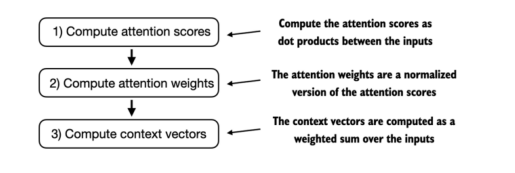

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("atn_steps.png")

plt.imshow(img)
plt.axis("off")
plt.show()

##### we follow the same three steps as before,except that we make a few modifications in the code to compute all context vectors instead of only the first context vector

In [18]:
print(inputs.shape)

torch.Size([6, 3])


##### attention score between two tokens is computed  using the dot product of every token with every other token.so, the attention score would look something like this

##### each token will do dot product with every other token, and we would get a 6*6 matrix where,

In [19]:
attn_scores =torch.empty(6,6)
for i in range(len(inputs)):
    for j in range(len(inputs)):
        attn_scores[i,j]=torch.dot(inputs[i],inputs[j])
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### Each element in the preceding tensor represents an attention score between each pair of inputs. right now these values are not normalized.

In [20]:
print(attn_scores.sum())

tensor(29.0070)


##### we need to normalize the attention score to get the attention weights,but before that:

##### When computing the preceding attention score tensor, we used for-loops in Python.However, for-loops are generally slow, and we can achieve the same results using matrix multiplication:


In [21]:
attn_scores=inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### as we  can see,we used matrix multiplication which are faster and best to use 

##### now we normalize these values to get the attention weights,in order to do that we use sotfmax function in torch

In [22]:
attn_weights=torch.softmax(attn_scores,dim=1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


##### these values are now normalized

##### each row represents the attention weights for each token,we can  check to see if the sum of those weights for single row is 1 or not

In [23]:
print(attn_weights[0].sum()) 

tensor(1.0000)


In [24]:
print(attn_weights[2].sum()) 

tensor(1.0000)


##### the final step is to compute the context vector for every input token. earlier, we calculated the context vector for only a single token to understand how self-attention works. we now repeat the same process for each of the 6 input tokens. as a result, we obtain 6 context vectors,one corresponding to each input token.

##### to do that , we just need to perform matrix multiplication of input with the attention weights

In [25]:
all_context_vecs= attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


##### in the resulting output tensor, each row contains a 3-dimensional context vector:

##### if we look  up the previous context vector we generated for first input ie,tensor([0.4421, 0.5931, 0.5790]) we can see that its same. so its working

##### this completes the walkthrough of simple self-attention mechanism,next we will add trainable weights, enabling the LLM to learn from data and improve its performance on specific tasks.

# Chapter 3.4.1 - Computing the attention weights step by step

##### we will implement the self attention mechanism step by step by introducing the three trainable weight matrices ie,Wq Wk,,Wv also known as the query,key,value(qkv matrices)

##### for this chapter, unlike the last where i used the first token inputs[0], i will use inputs[1] ie second token cause its whats the book uses and more easier to follow

##### till now we computed attention directly from the input embeddings

##### Simple Attention Mechanism

```text
Input Embeddings
        │
        ▼
   Dot Product
        │
        ▼
Attention Scores
        │
     Softmax
        │
        ▼
Attention Weights
```

##### we computed attention directly from the input embeddings. There were no learnable parameters, so the attention scores depended entirely on the input embeddings themselves. no learning was taking place

##### In this section, we introduce three learnable weight matrices: `W_query`, `W_key`, and `W_value`. Each input embedding is multiplied by these matrices to produce its corresponding Query (Q), Key (K), and Value (V) vectors.

##### Instead of using the raw input embeddings to compute attention, we now use the Query and Key vectors to calculate the attention scores. After applying softmax to obtain the attention weights, these weights are used with the Value vectors to compute the final context vector.

##### This is the core idea behind self-attention in transformers. The learnable weight matrices allow the model to learn better representations of the input during training, enabling it to capture more meaningful relationships between tokens.

In [26]:
x2=inputs[1]
dim_input=inputs.shape[1]
dim_output=2 
print(x2)
print(dim_input)
print(dim_output)

tensor([0.5500, 0.8700, 0.6600])
3
2


##### Note that in GPT-like models, the input and output dimensions are usually the same, but for illustration purposes, to better follow the computation, we choose different input (d_in=3) and output (d_out=2) dimensions here.

##### next we initialize the qkv matrices

In [27]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(dim_input, dim_output), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(dim_input, dim_output), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(dim_input, dim_output), requires_grad=False)

##### The above code initializes three random weight matrices: `W_query`, `W_key`, and `W_value`. These matrices are used to transform each input embedding into its corresponding Query (Q), Key (K), and Value (V) vectors for the self-attention mechanism. In this example, the weights are fixed (`requires_grad=False`) and are not updated during training.

##### but if we were to use the weight matrices for model training, we would set requires_grad=True to update these matrices during model training.

##### Each weight matrix has a shape of `(3, 2)`, where `3` is the input embedding dimension (`dim_input`) and `2` is the output dimension (`dim_output`).

In [28]:
print(W_query)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


##### think of it as these weights matrices with shape (3, 2) that maps a 3-dimensional input to a 2-dimensional output.

In [29]:
W_query.shape

torch.Size([3, 2])

##### now,we compute the query, key, and value vector we just multiply our input with its corresponding wq,wk,wv matrices

In [30]:
query_2= x2 @ W_query
key_2=x2 @ W_key 
value_2= x2 @ W_value 

In [31]:
print(query_2)

tensor([0.4306, 1.4551])


##### As we can see based on the output for the query, this results in a 2-dimensional vectorsince we set the number of columns of the corresponding weight matrix, via dim_output, to 2:

In [32]:
print(key_2)

tensor([0.4433, 1.1419])


In [33]:
print(value_2)

tensor([0.3951, 1.0037])


WEIGHT PARAMETERS VS ATTENTION WEIGHTS
Note that in the weight matrices W, the term "weight" is short for "weight
parameters," the values of a neural network that are optimized during training. This
is not to be confused with the attention weights. As we already saw in the previous
section, attention weights determine the extent to which a context vector depends on
the different parts of the input, i.e., to what extent the network focuses on different
parts of the input.
In summary, weight parameters are the fundamental, learned coefficients that define
the network's connections, while attention weights are dynamic, context-specific
values.

##### Even though our temporary goal is to only compute the one context vector,z, we still  require the key and value vectors for all input elements as they are involved in computing the attention weights with respect to the query q

In [34]:
keys=inputs @ W_key
values=inputs @ W_value

In [35]:
print(keys.shape)
print(values.shape)

torch.Size([6, 2])
torch.Size([6, 2])


##### we successfully projected the 6 input tokens from a 3D onto a 2D embedding space

##### The second step is now to compute the attention scores

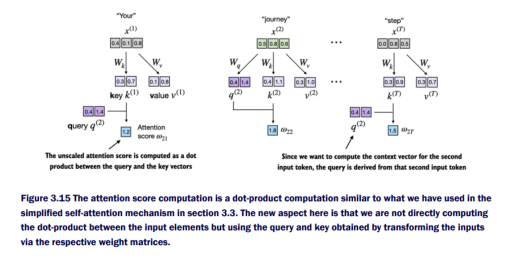

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("3.15.png")

plt.imshow(img)
plt.axis("off")
plt.show()

##### Before computing the attention scores, let's summarize the shapes, sizes, matrices, and vectors involved.

We start with the **input embeddings**, which have a shape of **6 × 3**. This means there are **6 input tokens**, and each token is represented by a **3-dimensional embedding**. In other words, each individual input token is a **1 × 3** vector, and stacking all 6 tokens together gives the input matrix of shape **6 × 3**.

Next, we introduce three learnable weight matrices:

- **WQ** → **3 × 2**
- **WK** → **3 × 2**
- **WV** → **3 × 2**

Each of these matrices projects the original **3-dimensional** embeddings into a new **2-dimensional** space.

For each input token (**1 × 3**), we perform matrix multiplication with each weight matrix:

- **Input (1 × 3) × WQ (3 × 2) → Query vector (1 × 2)**
- **Input (1 × 3) × WK (3 × 2) → Key vector (1 × 2)**
- **Input (1 × 3) × WV (3 × 2) → Value vector (1 × 2)**

Repeating this for all **6** input tokens gives three matrices:

- **Q:** 6 × 2
- **K:** 6 × 2
- **V:** 6 × 2

##### Computing the Attention Scores

Now we are ready to compute the **attention scores**. For each token, we take its **query vector** and compute the **dot product** with the **key vector of every token** (including itself). This tells us how much attention that token should pay to every other token in the sequence.

Computing all these dot products results in a **6 × 6 attention score matrix**, where:

- Each **row** corresponds to one **query token**.
- Each **column** corresponds to one **key token**.
- Each element **score(i, j)** represents the attention score between the **query of token _i_** and the **key of token _j_**.

##### now let's compute the attention score \(w_{22}\), which represents the attention score of the second input token with respect to the second input token.

##### to calcuate attention score we just take the query of the input and multiply with the key.

In [37]:
keys_2= keys[1] # ie keys[1] is journey, save the keys1 value in keys 2
attn_score=query_2.dot(keys_2) ##dot prodcut, multiply and sum,from this we will get one attention score 
print(attn_score) #this is one single attention score for query2

tensor(1.8524)


##### we can generalize this computation to all attention scores via matrix multiplication:

In [38]:
attn_scores_2= query_2 @ keys.T 
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


##### the third step is now going from the attention scores to the attention weights

In [39]:
keys.shape

torch.Size([6, 2])

In [40]:
print(keys[0].shape)

torch.Size([2])


In [41]:
print(keys.shape[-1])

2


In [42]:
key_dim=keys.shape[-1]
attn_weights_2=torch.softmax(attn_scores_2/key_dim**0.5,dim=-1)

In [43]:
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


##### the final step is to compute the context vectors

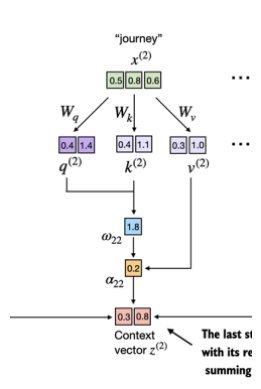

In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("3.17.png")

plt.imshow(img)
plt.axis("off")
plt.show()

##### If we look at the figure, we started with the token **"journey"** and its input embedding. We multiplied this embedding by the **Query (Q)**, **Key (K)**, and **Value (V)** weight matrices to obtain its corresponding **query**, **key**, and **value** vectors. Next, we computed the **dot product** between the query vector and the key vectors to obtain the **attention scores**. These scores were then normalized using **softmax** to produce the **attention weights**. now, we , we multiply the **attention weights** by the **value vectors** and sum the results to obtain the **context vector** for the token **"journey"**.

In [45]:
values.shape

torch.Size([6, 2])

In [46]:
attn_weights_2.shape

torch.Size([6])

In [47]:
context_vec2= attn_weights_2 @ values
print(context_vec2)
#so we have attention weights of 1*6, values of 6*2, matrix multipcaton between  will give a resultant matrix of 1*2

tensor([0.3061, 0.8210])


# Chapter 3.4.2 - Implementing a compact self-attention Python class

In [48]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()
        self.output_dim=output_dim
        self.W_query=nn.Parameter(torch.rand(input_dim,output_dim))
        self.W_key=nn.Parameter(torch.rand(input_dim,output_dim))
        self.W_value=nn.Parameter(torch.rand(input_dim,output_dim))

    def forward(self,x):
        queries= x @ self.W_query
        keys= x @ self.W_key
        values=x @self.W_value
        attn_scores= queries @ keys.T
        attn_weights= torch.softmax(attn_scores/(keys.shape[-1] ** 0.5) ,dim=-1)
        context_vec= attn_weights @ values
        return context_vec

In [49]:
torch.manual_seed(123)
sa_v1=SelfAttention_v1(dim_input,dim_output) #pass the dimensions we define in 3.4.1 ie 3,2
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


##### we can improve the SelfAttention_v1 implementation further by utilizing PyTorch's nn.Linear layers, which effectively perform matrix multiplication when the bias units are disabled. Additionally, a significant advantage of using nn.Linear instead of manually implementing nn.Parameter(torch.rand(...)) is that nn.Linear has an optimized weight initialization scheme, contributing to more stable and effective model training.

In [53]:
class SelfAttention_v2(nn.Module):
    def __init__(self,input_dim, output_dim, qkv_bias=False):
        super().__init__()
        self.output_dim=output_dim
        self.W_query=nn.Linear(input_dim,output_dim,bias=qkv_bias)
        self.W_key=nn.Linear(input_dim,output_dim,bias=qkv_bias)
        self.W_value=nn.Linear(input_dim,output_dim,bias=qkv_bias)

    def forward(self,x):
        keys=self.W_key(x)
        queries= self.W_query(x) # automatically perfroms : x @ self.W_key.weight.T
        values= self.W_value(x)
        attn_scores=queries @ keys.T
        attn_weights= torch.softmax(attn_scores/keys.shape[-1]**0.5 ,dim=-1)
        context_vec= attn_weights @ values
        return context_vec

In [54]:
torch.manual_seed(789)
sa_v2= SelfAttention_v2(dim_input,dim_output)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


##### Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because they use different initial weights for the weight matrices since nn.Linear uses a more sophisticated weight initialization scheme.

##### Note that nn.Linear in SelfAttention_v2 uses a different weight initialization scheme as nn.Parameter(torch.rand(d_in, d_out)) used in SelfAttention_v1, which causes both mechanisms to produce different results. To check that both implementations, SelfAttention_v1 and SelfAttention_v2, are otherwise similar, we can transfer the weight matrices from a SelfAttention_v2 object to a SelfAttention_v1, such that both objects then produce the same results.

##### The difference isn't in the attention mechanism itself. It's in how the weights are initialized.

##### In the next section, we will make enhancements to the self-attention mechanism, focusing specifically on incorporating causal and multi-head elements. The causal aspect involves modifying the attention mechanism to prevent the model from accessing future information in the sequence, which is cruciall for tasks like language modeling, where each word prediction should only depend on previous words.

##### The multi-head component involves splitting the attention mechanism into multiple "heads." Each head learns different aspects of the data, allowing the model to simultaneously attend to information from different representation subspaces at different positions. This improves the model's performance in complex tasks.

# Chapter 3.5 - Hiding future words with causal attention